In [ ]:
!nvidia-smi

Sat Mar  8 19:57:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import cv2
import numpy as np
import os
import time
from matplotlib import pyplot as plt
import yaml

import torch
import torchvision
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!curl -L "https://app.roboflow.com/ds/EwNZnLukt9?key=Ve7xemRHXk" > roboflow.zip; unzip roboflow.zip -d roboflow

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   3253      0 --:--:-- --:--:-- --:--:--  3259
100 1829M  100 1829M    0     0  74.3M      0  0:00:24  0:00:24 --:--:-- 92.4M
Archive:  roboflow.zip
 extracting: roboflow/README.roboflow.txt  
 extracting: roboflow/data.yaml      
   creating: roboflow/test/
   creating: roboflow/test/images/
 extracting: roboflow/test/images/frame_120_jpg.rf.e1d733638b90bae429fe73a2dde24341.jpg  
 extracting: roboflow/test/images/frame_132_jpg.rf.ddfd5d005afc3548b75f6da2e09ea856.jpg  
 extracting: roboflow/test/images/frame_146_jpg.rf.2a9d5f8b9ef3995191bd2724fbc5dc92.jpg  
 extracting: roboflow/test/images/frame_14_jpg.rf.638b5e89922c9ff19e42e7bc9973e80a.jpg  
 extracting: roboflow/test/images/frame_153_jpg.rf.8ac211b3928f9788fc9468c34bdd1d1a.jpg  
 extracting: roboflow/test/images/frame_156_jpg.rf.35fd85ed88de13ef

In [ ]:
!yolo checks

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 36.8/112.6 GB disk)

OS                  Linux-6.1.85+-x86_64-with-glibc2.35
Environment         Colab
Python              3.11.11
Install             pip
RAM                 12.67 GB
Disk                36.8/112.6 GB
CPU                 Intel Xeon 2.20GHz
CPU count           2
GPU                 Tesla T4, 15095MiB
GPU count           1
CUDA                12.4

numpy               ✅ 1.26.4<=2.1.1,>=1.23.0
matplotlib          ✅ 3.10.0>=3.3.0
opencv-python       ✅ 4.11.0.86>=4.6.0
pillow              ✅ 11.1.0>=7.1.2
pyyaml              ✅ 6.0.2>=5.3.1
requests            ✅ 2.32.3>=2.23.0
scipy               ✅ 1.13.1>=1.4.1
torch               ✅ 2.5.1+cu124>=1.8.0
torch               ✅ 2.5.1+cu124!=2.4.0,>=1.8.0; sys_platform == "win32"
torchvision         ✅ 0.20.1+cu124>=0.9.0
tqdm                ✅ 4.67.1>=4.64.0
psutil              ✅ 5.9.5
py-cpuinfo          ✅ 9.0.0

# train

In [ ]:
model = YOLO('yolov8n-seg.pt')
from torch.quantization import quantize_dynamic
model = quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)

100%|██████████| 6.74M/6.74M [00:00<00:00, 132MB/s]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(model.info())

YOLOv8n-seg summary: 151 layers, 3,409,968 parameters, 0 gradients, 12.8 GFLOPs
(151, 3409968, 0, 12.772710400000001)


In [ ]:
print(device)

cuda



0: 384x640 1 fire hydrant, 66.8ms
Speed: 13.0ms preprocess, 66.8ms inference, 350.7ms postprocess per image at shape (1, 3, 384, 640)
<class 'list'>
1
(2160, 3840, 3)


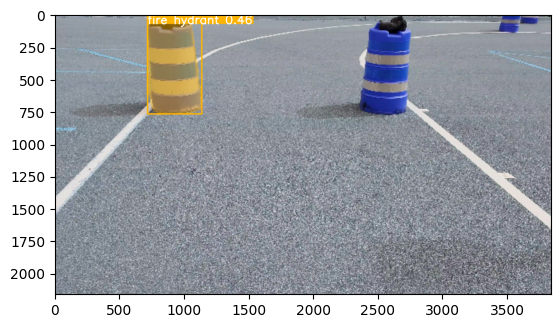

In [ ]:
sample_path = "/content/roboflow/train/images/frame_186_jpg.rf.58dcf643b43533c770deeb3122032748.jpg"
sample = cv2.imread(sample_path)
out = model(sample)
print(type(out))
print(len(out))
print(sample.shape)
for r in out:
    im = r.plot()
cv2.imwrite('./sample_out.jpg', im)
plt.imshow(im)

In [ ]:
!ls


roboflow  roboflow.zip	sample_out.jpg	yolov8n-seg.pt


In [ ]:
'''
yaml_path = '/content/roboflow/data.yaml'
results = model.train(data=yaml_path,
                    batch=16,
                    epochs=1,
                    device=device,
                    resume=True)

weights_path = './weights.pt'
print("done, saving to", weights_path)
torch.save(model.state_dict(), weights_path)
'''

'\nyaml_path = \'/content/roboflow/data.yaml\'\nresults = model.train(data=yaml_path,\n                    batch=16,\n                    epochs=1,\n                    device=device,\n                    resume=True)\n\nweights_path = \'./weights.pt\'\nprint("done, saving to", weights_path)\ntorch.save(model.state_dict(), weights_path)\n'

In [ ]:
import site
import ultralytics
print(ultralytics.__file__)

/usr/local/lib/python3.11/dist-packages/ultralytics/__init__.py


In [ ]:
!yolo model=yolov8n-seg.pt data = '/content/roboflow/data.yaml' device=cuda epochs=20 imgsz=608

WARNING ⚠️ 'mode' argument is missing. Valid modes are frozenset({'track', 'benchmark', 'train', 'export', 'val', 'predict'}). Using default 'mode=train'.
Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/roboflow/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=608, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=No

In [ ]:
from IPython.display import Image
import glob

In [ ]:
!yolo version

8.3.78


In [ ]:
!yolo mode=val model=/content/runs/segment/train/weights/best.pt data=/content/roboflow/data.yaml device=cuda

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,454 parameters, 0 gradients, 12.0 GFLOPs
val: Scanning /content/roboflow/valid/labels.cache... 199 images, 0 backgrounds, 0 corrupt: 100% 199/199 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 13/13 [00:13<00:00,  1.02s/it]
                   all        199       1257      0.935      0.901      0.952       0.86      0.912      0.857      0.926      0.663
                  lane        198        730      0.957      0.883      0.943       0.84      0.912      0.823      0.903      0.663
                 pylon        154        527      0.913      0.918      0.961       0.88      0.912       0.89      0.949      0.663
Speed: 1.3ms preprocess, 4.4ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/segment/val
💡 Learn more at https://

In [ ]:
!zip -r runs.zip runs

  adding: runs/ (stored 0%)
  adding: runs/segment/ (stored 0%)
  adding: runs/segment/val/ (stored 0%)
  adding: runs/segment/val/MaskPR_curve.png (deflated 16%)
  adding: runs/segment/val/confusion_matrix.png (deflated 35%)
  adding: runs/segment/val/val_batch2_pred.jpg (deflated 5%)
  adding: runs/segment/val/BoxPR_curve.png (deflated 18%)
  adding: runs/segment/val/BoxP_curve.png (deflated 15%)
  adding: runs/segment/val/MaskF1_curve.png (deflated 12%)
  adding: runs/segment/val/val_batch0_pred.jpg (deflated 5%)
  adding: runs/segment/val/confusion_matrix_normalized.png (deflated 35%)
  adding: runs/segment/val/val_batch1_pred.jpg (deflated 5%)
  adding: runs/segment/val/BoxF1_curve.png (deflated 12%)
  adding: runs/segment/val/MaskP_curve.png (deflated 17%)
  adding: runs/segment/val/val_batch0_labels.jpg (deflated 5%)
  adding: runs/segment/val/BoxR_curve.png (deflated 13%)
  adding: runs/segment/val/val_batch1_labels.jpg (deflated 5%)
  adding: runs/segment/val/MaskR_curve.png (

In [ ]:
!ls /usr/local/lib/python3.10/dist-packages/ultralytics/cfg

ls: cannot access '/usr/local/lib/python3.10/dist-packages/ultralytics/cfg': No such file or directory


##test

In [ ]:
!yolo mode=predict model=/content/runs/segment/train/weights/best.pt device=cuda source = /content/roboflow/test/images

Ultralytics 8.3.78 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,454 parameters, 0 gradients, 12.0 GFLOPs

image 1/99 /content/roboflow/test/images/frame_120_jpg.rf.e1d733638b90bae429fe73a2dde24341.jpg: 352x608 5 lanes, 4 pylons, 47.1ms
image 2/99 /content/roboflow/test/images/frame_132_jpg.rf.ddfd5d005afc3548b75f6da2e09ea856.jpg: 352x608 5 lanes, 4 pylons, 8.2ms
image 3/99 /content/roboflow/test/images/frame_146_jpg.rf.2a9d5f8b9ef3995191bd2724fbc5dc92.jpg: 352x608 4 lanes, 4 pylons, 8.3ms
image 4/99 /content/roboflow/test/images/frame_14_jpg.rf.638b5e89922c9ff19e42e7bc9973e80a.jpg: 352x608 2 lanes, 2 pylons, 8.3ms
image 5/99 /content/roboflow/test/images/frame_153_jpg.rf.8ac211b3928f9788fc9468c34bdd1d1a.jpg: 352x608 4 lanes, 4 pylons, 8.0ms
image 6/99 /content/roboflow/test/images/frame_156_jpg.rf.35fd85ed88de13ef355afbefbd33d876.jpg: 352x608 5 lanes, 4 pylons, 8.2ms
image 7/99 /content/roboflow/test/images/frame_166_jpg.r

In [ ]:
for path in glob.glob(os.path.join('/content/runs/segment/predict/', '*.jpg')):
    print(path)
    display(Image(path, height=300))

NameError: name 'glob' is not defined

In [ ]:
model = YOLO('/content/runs/segment/train/weights/best.pt')


0: 352x608 5 lanes, 4 pylons, 44.6ms
Speed: 2.4ms preprocess, 44.6ms inference, 3.4ms postprocess per image at shape (1, 3, 352, 608)
<class 'list'>
1
(2160, 3840, 3)


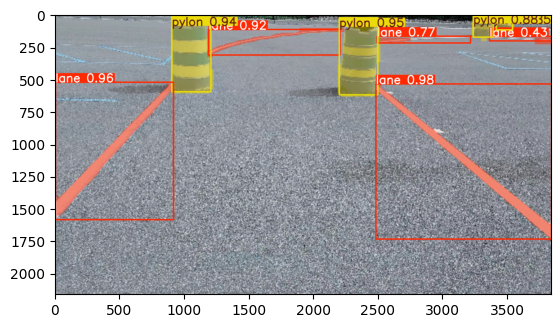

In [ ]:
sample_path = "/content/roboflow/train/images/frame_113_jpg.rf.91e57d7c8997ffb2449b32c1839c5745.jpg"
sample = cv2.imread(sample_path)
out = model(sample)
print(type(out))
print(len(out))
print(sample.shape)
for r in out:
    im = r.plot()
cv2.imwrite('./sample_out.jpg', im)
plt.imshow(im)

In [ ]:
print(model.info())

YOLOv8n-seg summary (fused): 85 layers, 3,258,454 parameters, 0 gradients, 12.0 GFLOPs
(85, 3258454, 0, 11.9741952)


In [ ]:
torch.save(model.state_dict(), 'quantizied_model_weights.pth')